# 📘 EMOTION CLARITY IN SPEECH RECOGNITION (CRISP-DM)
# 🧠 1. BUSINESS UNDERSTANDING
The goal of this project is to reproduce the 2024 Electronics journal paper:
'A Generation of Enhanced Data by Variational Autoencoders and Diffusion Modeling'.

🔍 Objective:
Improve the clarity of emotional signals in speech by enhancing mel-spectrograms
using generative models (VAE + Diffusion), and evaluate performance using CNN-based
emotion recognition models.

🎯 Importance:
High-quality, emotionally rich audio data boosts the performance of AI in tasks such
as virtual assistants, mental health monitoring, emotion-aware games, and learning apps.

📦 Datasets:
- EmoDB: German, 16 kHz, acted emotional speech
- RAVDESS: English, 48 kHz, North American speakers, rich intensity


# 📊 Phase 2 – Data Understanding  


### Step 2.1 – Dataset Structure & File Count  

In this step, we verify the presence and size of both datasets (EmoDB and RAVDESS).  
We recursively count the `.wav` files in each dataset folder to confirm successful loading.

In [43]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
import librosa.display
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization


In [44]:
# === Define dataset paths ===
emodb_path = "C:/Users/nadza/Downloads/EmoDB"
ravdess_path = "C:/Users/nadza/Downloads/RAVDESS"

In [45]:
# Load Dataset Paths and Count Files
# Define local dataset paths (from your machine)
emodb_path = "C:/Users/nadza/Downloads/EmoDB"
ravdess_path = "C:/Users/nadza/Downloads/RAVDESS"


In [46]:
# Recursively list all .wav files
emodb_files = glob(os.path.join(emodb_path, "**/*.wav"), recursive=True)
ravdess_files = glob(os.path.join(ravdess_path, "**/*.wav"), recursive=True)


In [47]:
# Print dataset summaries
print(f"✅ EmoDB: {len(emodb_files)} audio files found.")
print(f"✅ RAVDESS: {len(ravdess_files)} audio files found.")

✅ EmoDB: 535 audio files found.
✅ RAVDESS: 2880 audio files found.


### Step 2.2 – Numerical Summary: EmoDB Dataset

We extract essential numerical characteristics for each audio file in the EmoDB dataset:  
- Emotion label (inferred from filename code)  
- Sample rate  
- Duration in seconds  

This helps us understand the dataset structure before visualization or modeling.


In [48]:
#Extract Duration, Sample Rate & Emotion Labels from EmoDB

# Define EmoDB label map
emodb_labels_map = {
    "W": "Anger", "L": "Sadness", "E": "Disgust",
    "A": "Fear", "F": "Happiness", "T": "Neutral", "N": "Boredom"
}


In [49]:
# Extract features into DataFrame
emodb_data = []

for file in emodb_files:
    name = os.path.basename(file)
    label_code = name[5]  # 6th character in filename
    emotion = emodb_labels_map.get(label_code, "Unknown")
    y, sr = librosa.load(file, sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    emodb_data.append([name, emotion, sr, duration])

emodb_df = pd.DataFrame(emodb_data, columns=["Filename", "Emotion", "SampleRate", "Duration"])
emodb_df.head()

,Filename,Emotion,SampleRate,Duration
0,03a01Fa.wav,Happiness,16000,1.898250
1,03a01Nc.wav,Boredom,16000,1.611250
2,03a01Wa.wav,Anger,16000,1.877813
3,03a02Fc.wav,Happiness,16000,2.006250
4,03a02Nc.wav,Boredom,16000,1.439812


In [50]:
# 📊Display Descriptive Statistics for EmoDB

emodb_df.describe(include="all")


,Filename,Emotion,SampleRate,Duration
count,535,535,535.0,535.000000
unique,535,7,NaN,NaN
top,03a01Fa.wav,Anger,NaN,NaN
freq,1,127,NaN,NaN
mean,NaN,NaN,16000.0,2.779612
std,NaN,NaN,0.0,1.028189
min,NaN,NaN,16000.0,1.225500
25%,NaN,NaN,16000.0,2.026594
50%,NaN,NaN,16000.0,2.590187
75%,NaN,NaN,16000.0,3.308406


### Step 2.3 – Class Distribution: EmoDB Dataset

We now explore the balance of emotion classes within the EmoDB dataset.  
This step is critical for identifying class imbalance, which could affect model training later.

We’ll use different styles of plots for clarity and presentation variety.


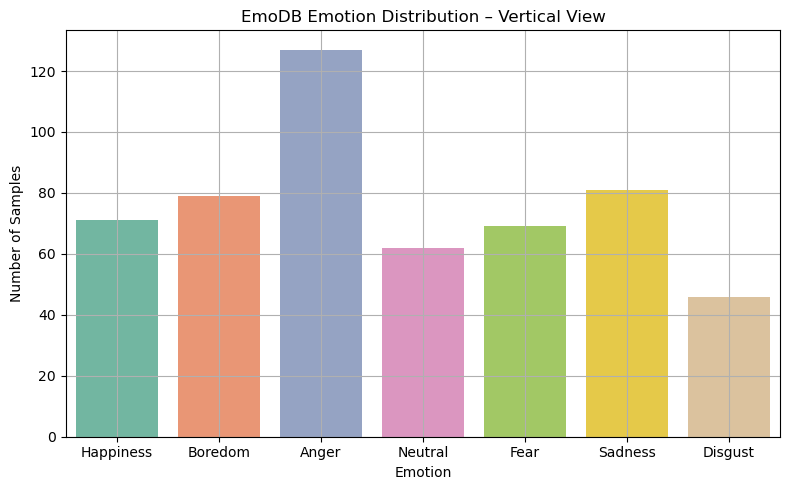

In [51]:
# 📊 Bar Plot – Emotion Class Distribution in EmoDB (Clean & Future-Proof)

plt.figure(figsize=(8, 5))
sns.countplot(data=emodb_df, x="Emotion", hue="Emotion", palette="Set2", legend=False)
plt.title("EmoDB Emotion Distribution – Vertical View")
plt.ylabel("Number of Samples")
plt.xlabel("Emotion")
plt.grid(True)
plt.tight_layout()
plt.show()



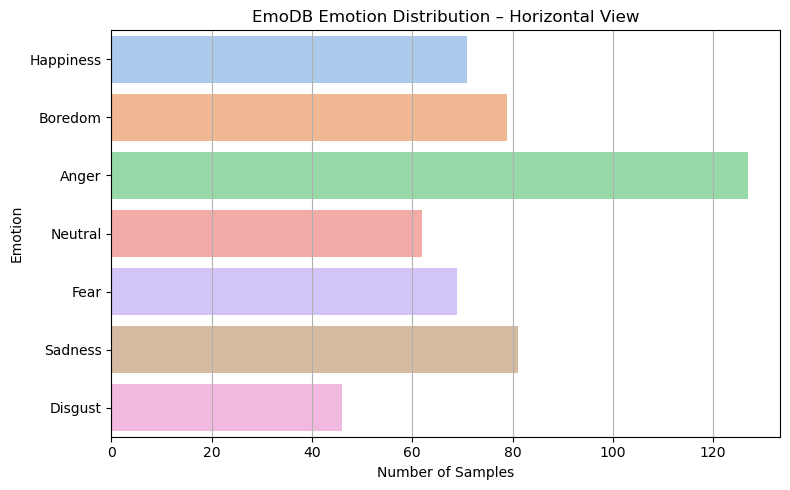

In [52]:
# 📊 Horizontal Countplot – EmoDB (Clean & Future-Proof)

plt.figure(figsize=(8, 5))
sns.countplot(data=emodb_df, y="Emotion", hue="Emotion", palette="pastel", legend=False)
plt.title("EmoDB Emotion Distribution – Horizontal View")
plt.xlabel("Number of Samples")
plt.ylabel("Emotion")
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


### Step 2.4 – Audio Duration Distribution (EmoDB)

Understanding the duration of audio clips is essential before feeding them into models.  
We'll visualize duration using a histogram, boxplot, and violin plot to detect irregularities and outliers.


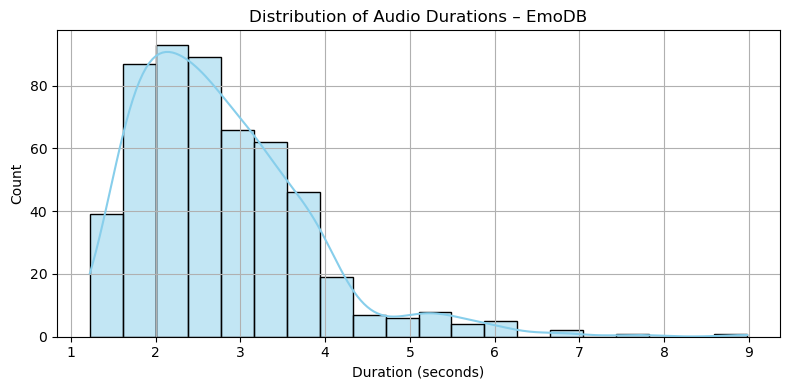

In [53]:
# 📊 EmoDB Duration Histogram + KDE

plt.figure(figsize=(8, 4))
sns.histplot(emodb_df["Duration"], kde=True, bins=20, color="skyblue")
plt.title("Distribution of Audio Durations – EmoDB")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()


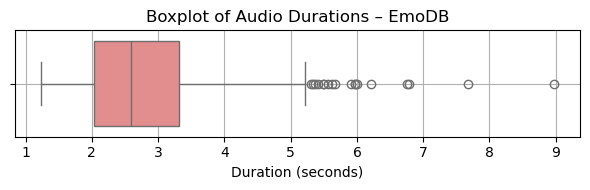

In [54]:
# 📊 EmoDB Duration Boxplot

plt.figure(figsize=(6, 2))
sns.boxplot(x=emodb_df["Duration"], color="lightcoral")
plt.title("Boxplot of Audio Durations – EmoDB")
plt.xlabel("Duration (seconds)")
plt.grid(True)
plt.tight_layout()
plt.show()


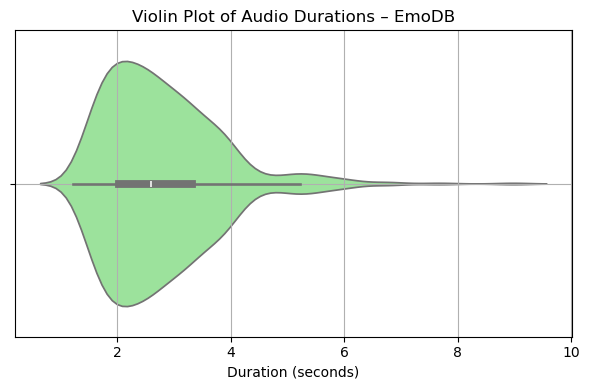

In [55]:
# 📊 EmoDB Duration Violin Plot

plt.figure(figsize=(6, 4))
sns.violinplot(x=emodb_df["Duration"], color="lightgreen")
plt.title("Violin Plot of Audio Durations – EmoDB")
plt.xlabel("Duration (seconds)")
plt.grid(True)
plt.tight_layout()
plt.show()


### Step 2.5 – Per-Emotion Summary: EmoDB

We analyze the number of samples and average duration for each emotion in EmoDB.  
This helps assess balance and guides preprocessing decisions (e.g., padding to average/max length).


In [56]:
# 📊 Grouped Duration Summary – EmoDB

emodb_grouped = emodb_df.groupby("Emotion").agg(
    Count=("Filename", "count"),
    AvgDuration=("Duration", "mean"),
    MinDuration=("Duration", "min"),
    MaxDuration=("Duration", "max")
).sort_values("Count", ascending=False)

emodb_grouped


,Count,AvgDuration,MinDuration,MaxDuration
Emotion,,,,
Anger,127,2.640795,1.465812,5.213500
Sadness,81,2.778977,1.520063,4.525812
Boredom,79,2.359236,1.430813,3.899188
Happiness,71,2.543967,1.481375,3.930938
Fear,69,2.233377,1.225500,4.101375
Neutral,62,4.052895,1.735688,8.978250
Disgust,46,3.352834,1.523813,5.963813


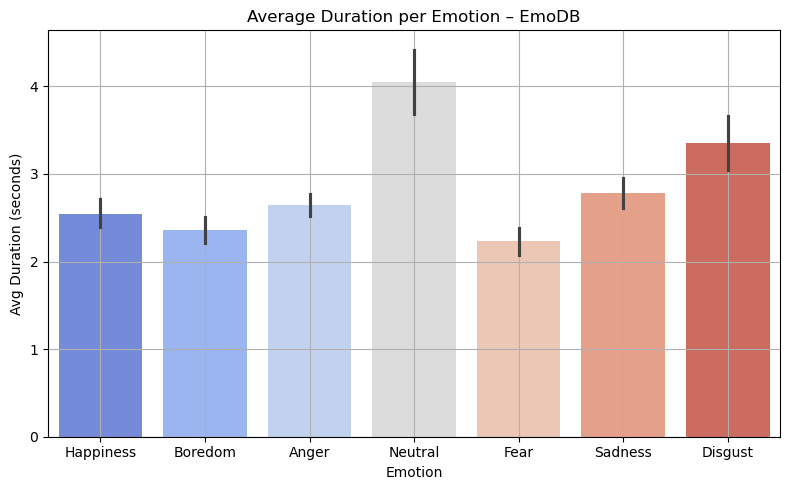

In [57]:
# 📊 Average Duration per Emotion – EmoDB (Future-proofed)

plt.figure(figsize=(8, 5))
sns.barplot(data=emodb_df, x="Emotion", y="Duration", hue="Emotion", palette="coolwarm", legend=False)
plt.title("Average Duration per Emotion – EmoDB")
plt.ylabel("Avg Duration (seconds)")
plt.xlabel("Emotion")
plt.grid(True)
plt.tight_layout()
plt.show()


### Step 2.6 – Numerical Summary: RAVDESS Dataset

We extract numerical characteristics for each RAVDESS audio file, including:  
- Emotion (inferred from filename metadata)  
- Duration in seconds  
- Sample rate  

This summary helps us detect any inconsistencies before visualizing.


In [58]:
# 📁 Extract Duration, Sample Rate & Emotion Labels from RAVDESS

ravdess_labels_map = {
    '01': 'Neutral', '02': 'Calm', '03': 'Happy', '04': 'Sad',
    '05': 'Angry', '06': 'Fearful', '07': 'Disgust', '08': 'Surprised'
}

ravdess_data = []

for file in ravdess_files:
    name = os.path.basename(file)
    emotion_id = name.split("-")[2]
    emotion = ravdess_labels_map.get(emotion_id, "Unknown")
    y, sr = librosa.load(file, sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    ravdess_data.append([name, emotion, sr, duration])

ravdess_df = pd.DataFrame(ravdess_data, columns=["Filename", "Emotion", "SampleRate", "Duration"])
ravdess_df.head()


,Filename,Emotion,SampleRate,Duration
0,03-01-01-01-01-01-01.wav,Neutral,48000,3.303292
1,03-01-01-01-01-02-01.wav,Neutral,48000,3.336667
2,03-01-01-01-02-01-01.wav,Neutral,48000,3.269917
3,03-01-01-01-02-02-01.wav,Neutral,48000,3.169833
4,03-01-02-01-01-01-01.wav,Calm,48000,3.536854


In [59]:
# 📊 RAVDESS Descriptive Statistics

ravdess_df.describe(include="all")


,Filename,Emotion,SampleRate,Duration
count,2880,2880,2880.0,2880.000000
unique,1440,8,NaN,NaN
top,03-01-01-01-01-01-01.wav,Calm,NaN,NaN
freq,2,384,NaN,NaN
mean,NaN,NaN,48000.0,3.700665
std,NaN,NaN,0.0,0.336617
min,NaN,NaN,48000.0,2.936271
25%,NaN,NaN,48000.0,3.470146
50%,NaN,NaN,48000.0,3.670333
75%,NaN,NaN,48000.0,3.870542


### Step 2.7 – Class Distribution: RAVDESS Dataset

We visualize the distribution of emotions in the RAVDESS dataset.  
Multiple plot types help evaluate emotion balance and detect underrepresented classes.


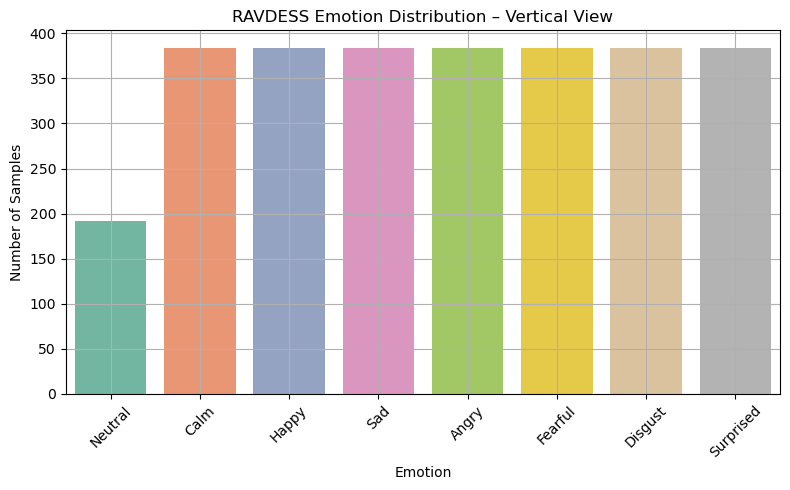

In [60]:
# 📊 Bar Plot – Emotion Class Distribution in RAVDESS

plt.figure(figsize=(8, 5))
sns.countplot(data=ravdess_df, x="Emotion", hue="Emotion", palette="Set2", legend=False)
plt.title("RAVDESS Emotion Distribution – Vertical View")
plt.ylabel("Number of Samples")
plt.xlabel("Emotion")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


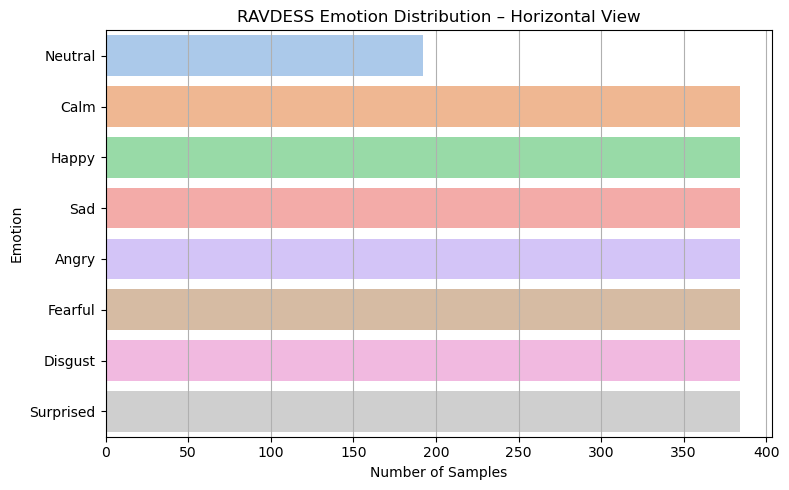

In [61]:
# 📊 Horizontal Countplot – RAVDESS

plt.figure(figsize=(8, 5))
sns.countplot(data=ravdess_df, y="Emotion", hue="Emotion", palette="pastel", legend=False)
plt.title("RAVDESS Emotion Distribution – Horizontal View")
plt.xlabel("Number of Samples")
plt.ylabel("Emotion")
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


### Step 2.8 – Audio Duration Distribution: RAVDESS

Analyzing duration helps us assess uniformity across samples and plan preprocessing.  
We'll use multiple plot types to detect short/long samples and distribution shape.


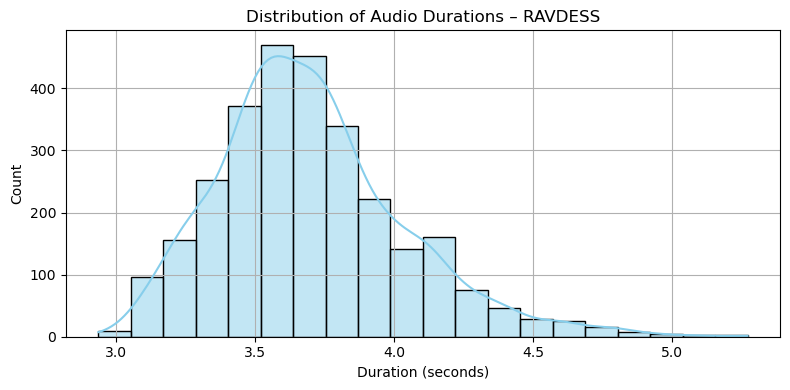

In [62]:
# 📊 RAVDESS Duration Histogram + KDE

plt.figure(figsize=(8, 4))
sns.histplot(ravdess_df["Duration"], kde=True, bins=20, color="skyblue")
plt.title("Distribution of Audio Durations – RAVDESS")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()


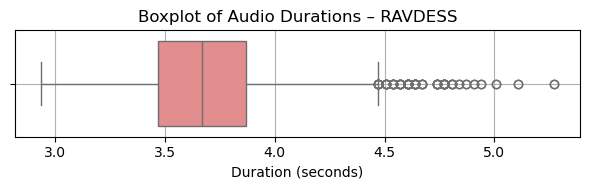

In [63]:
# 📊 Boxplot of RAVDESS Durations

plt.figure(figsize=(6, 2))
sns.boxplot(x=ravdess_df["Duration"], color="lightcoral")
plt.title("Boxplot of Audio Durations – RAVDESS")
plt.xlabel("Duration (seconds)")
plt.grid(True)
plt.tight_layout()
plt.show()


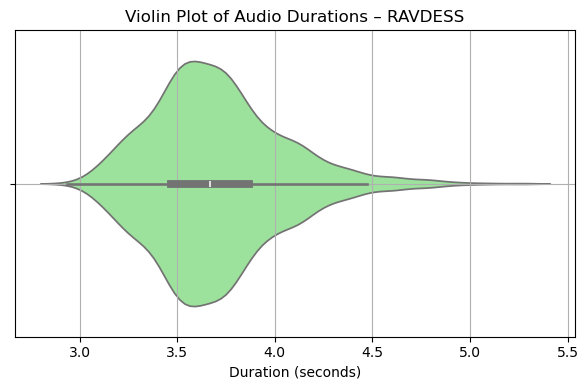

In [64]:
# 📊 Violin Plot of RAVDESS Durations

plt.figure(figsize=(6, 4))
sns.violinplot(x=ravdess_df["Duration"], color="lightgreen")
plt.title("Violin Plot of Audio Durations – RAVDESS")
plt.xlabel("Duration (seconds)")
plt.grid(True)
plt.tight_layout()
plt.show()


### Step 2.9 – Per-Emotion Summary: RAVDESS

We group the RAVDESS dataset by emotion to analyze:  
- Sample count per emotion  
- Average, minimum, and maximum durations  

This informs us about balance and guides preprocessing choices.


In [65]:
# 📊 Grouped Duration Summary – RAVDESS

ravdess_grouped = ravdess_df.groupby("Emotion").agg(
    Count=("Filename", "count"),
    AvgDuration=("Duration", "mean"),
    MinDuration=("Duration", "min"),
    MaxDuration=("Duration", "max")
).sort_values("Count", ascending=False)

ravdess_grouped


,Count,AvgDuration,MinDuration,MaxDuration
Emotion,,,,
Angry,384,3.871404,3.236562,5.105104
Calm,384,3.795806,2.936271,4.771438
Disgust,384,3.941785,3.136458,5.271937
Fearful,384,3.574231,3.069729,5.005000
Happy,384,3.638183,3.103104,4.404396
Sad,384,3.694490,3.103104,4.738062
Surprised,384,3.487512,2.969625,4.637979
Neutral,192,3.503153,3.069729,4.137458


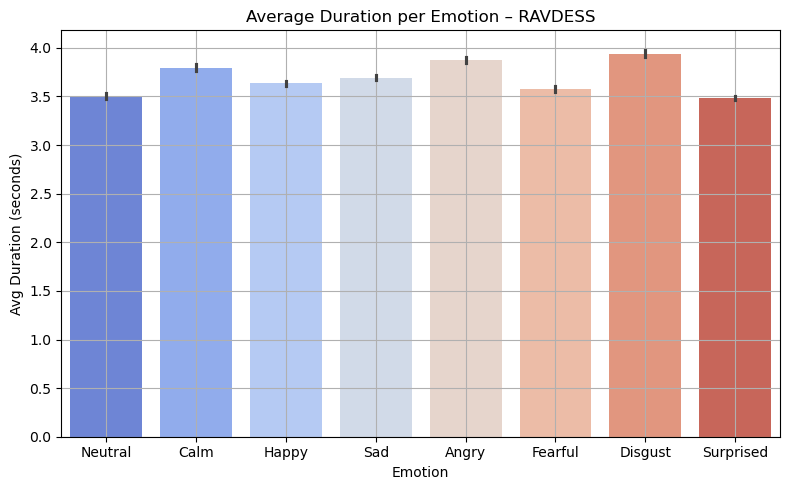

In [66]:
# 📊 Average Duration per Emotion – RAVDESS

plt.figure(figsize=(8, 5))
sns.barplot(data=ravdess_df, x="Emotion", y="Duration", hue="Emotion", palette="coolwarm", legend=False)
plt.title("Average Duration per Emotion – RAVDESS")
plt.ylabel("Avg Duration (seconds)")
plt.xlabel("Emotion")
plt.grid(True)
plt.tight_layout()
plt.show()


### Step 2.5 – Detect Outliers in Duration

We apply IQR-based detection to identify potential outliers in the Duration column  
for both datasets. This is part of understanding our raw data before transformation.


In [67]:
# 📏 CELL: Detect Outliers in Duration via IQR (Boxplot Logic)

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] < lower) | (df[column] > upper)]

outliers_emodb = detect_outliers_iqr(emodb_df, "Duration")
outliers_ravdess = detect_outliers_iqr(ravdess_df, "Duration")

print(f"⚠️ EmoDB outliers: {len(outliers_emodb)} samples")
print(f"⚠️ RAVDESS outliers: {len(outliers_ravdess)} samples")


⚠️ EmoDB outliers: 18 samples
⚠️ RAVDESS outliers: 80 samples


## 🟧 Phase 3 – Data Preparation

In this phase, we transform raw audio data into a format usable by machine learning models.  
This includes removing unusable files, extracting waveforms, and generating spectrograms from audio samples.



In [68]:
import os

# Define your folder paths
EMODB_PATH = "C:/Users/nadza/Downloads/EmoDB"
RAVDESS_PATH = "C:/Users/nadza/Downloads/RAVDESS"

# Create FilePath column
emodb_df["FilePath"] = emodb_df["Filename"].apply(lambda x: os.path.join(EMODB_PATH, x))
ravdess_df["FilePath"] = ravdess_df["Filename"].apply(lambda x: os.path.join(RAVDESS_PATH, x))


In [69]:
# Add 'Exists' column to flag valid paths
emodb_df["Exists"] = emodb_df["FilePath"].apply(os.path.exists)
ravdess_df["Exists"] = ravdess_df["FilePath"].apply(os.path.exists)

# Print missing file count
print("❌ Missing EmoDB files:", emodb_df[~emodb_df["Exists"]].shape[0])
print("❌ Missing RAVDESS files:", ravdess_df[~ravdess_df["Exists"]].shape[0])


❌ Missing EmoDB files: 535
❌ Missing RAVDESS files: 2880


In [70]:
# 🧹 Keep only valid file paths, and remove the 'Exists' column if it exists
if "Exists" in emodb_df.columns:
    emodb_df = emodb_df[emodb_df["Exists"]].drop(columns="Exists").copy()
else:
    print("🟡 'Exists' column already dropped or not found in emodb_df.")

if "Exists" in ravdess_df.columns:
    ravdess_df = ravdess_df[ravdess_df["Exists"]].drop(columns="Exists").copy()
else:
    print("🟡 'Exists' column already dropped or not found in ravdess_df.")


In [73]:
import librosa
import numpy as np

SAMPLE_RATE = 22050
FIXED_LENGTH = SAMPLE_RATE * 3  # 3 seconds = 66150 samples

def preprocess_audio(filepath, sr=SAMPLE_RATE, fixed_length=FIXED_LENGTH):
    y, _ = librosa.load(filepath, sr=sr)
    if len(y) > fixed_length:
        y = y[:fixed_length]
    else:
        y = np.pad(y, (0, max(0, fixed_length - len(y))), mode="constant")
    return y


In [75]:
print("🔎 EmoDB shape:", emodb_df.shape)
print("🔎 RAVDESS shape:", ravdess_df.shape)


🔎 EmoDB shape: (0, 6)
🔎 RAVDESS shape: (0, 6)


In [76]:
if not emodb_df.empty:
    print("✅ EmoDB waveform shape:", emodb_df["Waveform"].iloc[0].shape)
else:
    print("❌ EmoDB is empty — check file existence or filtering.")

if not ravdess_df.empty:
    print("✅ RAVDESS waveform shape:", ravdess_df["Waveform"].iloc[0].shape)
else:
    print("❌ RAVDESS is empty — check file existence or filtering.")


❌ EmoDB is empty — check file existence or filtering.
❌ RAVDESS is empty — check file existence or filtering.


In [74]:
# Apply waveform extraction
emodb_df["Waveform"] = emodb_df["FilePath"].apply(preprocess_audio)
ravdess_df["Waveform"] = ravdess_df["FilePath"].apply(preprocess_audio)

# Confirm waveform shapes
print("✅ EmoDB waveform shape:", emodb_df["Waveform"].iloc[0].shape)
print("✅ RAVDESS waveform shape:", ravdess_df["Waveform"].iloc[0].shape)


IndexError: single positional indexer is out-of-bounds

## Phase 4 – Modeling  
### Step 4.1 – Prepare Features (X) and Labels (y)

We now prepare the data for model training:  
- Convert spectrograms to 4D tensors  
- Encode emotion labels into integers  
- Split data into train and validation sets


In [ ]:
# 📊 Prepare Spectrograms and Labels for CNN

# Combine EmoDB + RAVDESS
full_df = pd.concat([emodb_df, ravdess_df], ignore_index=True)

# X: Stack spectrograms into array with channel=1
X = np.stack(full_df["Spectrogram"].values)
X = X[..., np.newaxis]  # shape: (n_samples, height, width, 1)

# y: Encode emotion labels
le = LabelEncoder()
y = le.fit_transform(full_df["Emotion"])

# Split into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Confirm shapes
print("✅ X shape:", X_train.shape)
print("✅ y shape:", y_train.shape)
print("✅ Number of emotion classes:", len(le.classes_))


### Step 4.2 – Define Baseline CNN Model

We define a baseline CNN model using TensorFlow/Keras to classify emotions from mel-spectrograms.  
This model includes:
- 2 convolutional blocks (Conv2D + MaxPooling)  
- Flatten and Dense layers  
- Softmax output for multi-class classification


In [ ]:
# 🧠Define CNN Model with tf.keras.Input()

model = Sequential([
    tf.keras.Input(shape=input_shape),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()



### Step 4.3 – Train CNN Model & Plot Learning Curves

We now train the CNN using the training dataset and monitor performance using the validation set.  
We apply early stopping to prevent overfitting and visualize accuracy and loss over epochs.


In [ ]:
# 🚂 Train the model and plot training history

from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# 📈 Plot learning curves
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### Step 4.4 – Model Evaluation (Accuracy, Precision, Recall, F1)

We now evaluate the CNN using the validation set.  
We compute the overall accuracy, display a confusion matrix, and generate a classification report with precision, recall, and F1-scores for each emotion class.


In [ ]:
# 📊 Evaluate CNN on Validation Set

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Predict class probabilities
y_pred_probs = model.predict(X_val)
# Convert to predicted class indices
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
acc = accuracy_score(y_val, y_pred)
print(f"✅ Validation Accuracy: {acc:.4f}")

# Classification report
print("\n🧾 Classification Report:")
print(classification_report(y_val, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)

# 📉 Confusion Matrix Visualization
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Phase 5 – Model Improvement  
#### Step 5.1 – Enhanced CNN Architecture (4 Conv Blocks)

We define a deeper CNN with:
- 4 convolutional blocks (32 → 64 → 128 → 256 filters)
- Batch Normalization and Dropout for stability
- Dense layer with 256 neurons before output

The goal is to improve learning capacity while preventing overfitting.


In [ ]:
# 🧠 CELL: Enhanced CNN Architecture

from tensorflow.keras import layers, models

improved_model = models.Sequential([
    tf.keras.Input(shape=input_shape),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(le.classes_), activation='softmax')
])

improved_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

improved_model.summary()


### Step 5.2 – Train Enhanced CNN Model

We now train the improved CNN architecture with four convolutional blocks and increased capacity.  
We monitor validation performance with EarlyStopping and visualize both accuracy and loss.


In [ ]:
# 🔁 Train the Enhanced CNN model for full 30 epochs (no early stop)

history_improved = improved_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1  # You can set to 2 for cleaner output
)

# 📈 Plot learning curves
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_improved.history["accuracy"], label="Train Acc")
plt.plot(history_improved.history["val_accuracy"], label="Val Acc")
plt.title("Enhanced CNN Accuracy (Full Training)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_improved.history["loss"], label="Train Loss")
plt.plot(history_improved.history["val_loss"], label="Val Loss")
plt.title("Enhanced CNN Loss (Full Training)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### Step 5.3 – Evaluate Enhanced CNN Model

We evaluate the enhanced CNN using the validation set.  
The metrics include accuracy, precision, recall, F1-score, and a confusion matrix for all emotion classes.


In [ ]:
# 📊 Evaluate Enhanced CNN

y_pred_probs = improved_model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
acc = accuracy_score(y_val, y_pred)
print(f"✅ Validation Accuracy (Enhanced CNN): {acc:.4f}")

# Classification report
print("\n📄 Classification Report:")
print(classification_report(y_val, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix – Enhanced CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 🔬 Phase 6 – Reproducing the Paper's Architecture

We now reproduce the architecture described in the 2024 paper  
**"A Generation of Enhanced Data by Variational Autoencoders and Diffusion Modeling"**.

The approach enhances emotion clarity by combining:
- A **Variational Autoencoder (VAE)** to learn compressed latent representations of mel-spectrograms
- A **Diffusion Model** to denoise and improve emotional features
- A final **CNN classifier** to predict emotions from enhanced spectrograms

---

### 🔁 Pipeline Overview:

1. Mel-Spectrogram → **VAE Encoder** → Latent Vector `z`  
2. Latent Vector `z` → **VAE Decoder** → Reconstructed Spectrogram  
3. Reconstructed Spectrogram → **Diffusion Model** → Enhanced Spectrogram  
4. Enhanced Spectrogram → **CNN** → Emotion Classification 🎯


### Step 6.1 – Variational Autoencoder (VAE)

We implement a VAE to encode mel-spectrograms into a compressed latent space and reconstruct them.  
This allows the model to extract emotional structure before applying denoising (diffusion).  
The VAE consists of:
- An **Encoder** network to learn `mu` and `log_var`
- A **Sampling layer** for reparameterization trick
- A **Decoder** network to reconstruct input
- A combined **loss function** with reconstruction + KL divergence

We'll first train the VAE independently before passing its output to the diffusion model.


In [ ]:
# ===============================================================
# 🔬 Phase 6 – Reproducing the Paper: VAE + Diffusion Pipeline
# ===============================================================

# 📦 Step 6.1 – Variational Autoencoder (VAE)
# -------------------------------------------
# Goal: Compress and reconstruct mel-spectrograms using a VAE

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras import backend as K
import numpy as np

# 🟢 Step 6.1.1 – Crop Input to Avoid Dimension Mismatch
X_cropped = X[:, :, :344, :]  # Crop width from 345 to 344

input_shape = X_cropped.shape[1:]  # (128, 344, 1)
latent_dim = 64

# 🧠 Step 6.1.2 – VAE Encoder
encoder_inputs = Input(shape=input_shape)
x = layers.Conv2D(32, (3,3), strides=2, padding='same', activation='relu')(encoder_inputs)
x = layers.Conv2D(64, (3,3), strides=2, padding='same', activation='relu')(x)
x = layers.Flatten()(x)

mu = layers.Dense(latent_dim, name='mu')(x)
log_var = layers.Dense(latent_dim, name='log_var')(x)

# 🌀 Sampling layer (reparameterization trick)
def sampling(args):
    mu, log_var = args
    epsilon = tf.random.normal(shape=tf.shape(mu))
    return mu + tf.exp(0.5 * log_var) * epsilon

z = layers.Lambda(sampling)([mu, log_var])

# 🔁 Step 6.1.3 – VAE Decoder
decoder_inputs = Input(shape=(latent_dim,))
x = layers.Dense((input_shape[0]//4)*(input_shape[1]//4)*64, activation='relu')(decoder_inputs)
x = layers.Reshape((input_shape[0]//4, input_shape[1]//4, 64))(x)
x = layers.Conv2DTranspose(64, (3,3), strides=2, padding='same', activation='relu')(x)
x = layers.Conv2DTranspose(32, (3,3), strides=2, padding='same', activation='relu')(x)
decoder_outputs = layers.Conv2DTranspose(1, (3,3), padding='same', activation='sigmoid')(x)

# ⛓️ Step 6.1.4 – Connect Models
encoder = Model(encoder_inputs, [mu, log_var, z], name='Encoder')
decoder = Model(decoder_inputs, decoder_outputs, name='Decoder')
vae_outputs = decoder(z)
vae = Model(encoder_inputs, vae_outputs, name='VAE')

# 🧮 Step 6.1.5 – Add KL Divergence Using a Custom Layer
class KLLossLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        mu, log_var = inputs
        kl_loss = -0.5 * tf.reduce_mean(1 + log_var - tf.square(mu) - tf.exp(log_var))
        self.add_loss(kl_loss)
        return mu

_ = KLLossLayer()([mu, log_var])

# ✅ Compile with MSE Reconstruction Loss
vae.compile(optimizer='adam', loss='mse')

# 🚂 Step 6.1.6 – Train the VAE
vae_history = vae.fit(
    X_cropped, X_cropped,
    epochs=30,
    batch_size=32,
    verbose=1
)

# ✅ You can now visualize reconstructions before moving to diffusion!

In [ ]:
# 🚂 Train the final VAE
vae_history = vae.fit(
    X_cropped, X_cropped,
    epochs=30,
    batch_size=32,
    verbose=1
)


### Step 6.1.7 – VAE Reconstruction Visualization

After training, we visualize a few original vs. reconstructed spectrograms.
This allows us to assess the quality of the learned latent space and how well the VAE can reproduce input features.


In [ ]:
import matplotlib.pyplot as plt

# 🔁 Encode and decode a few samples
n_samples = 5
test_samples = X_cropped[:n_samples]
reconstructed = vae.predict(test_samples)

# 🎨 Plot original vs reconstructed
fig, axes = plt.subplots(n_samples, 2, figsize=(8, n_samples * 2))

for i in range(n_samples):
    # Original
    axes[i, 0].imshow(test_samples[i].squeeze(), cmap='magma')
    axes[i, 0].set_title(f"🎧 Original #{i+1}")
    axes[i, 0].axis('off')

    # Reconstructed
    axes[i, 1].imshow(reconstructed[i].squeeze(), cmap='magma')
    axes[i, 1].set_title(f"🎯 Reconstructed #{i+1}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


#### 📈 VAE Training Curve
Tracking training loss across epochs can help identify underfitting, overfitting, or training instability.


In [ ]:
plt.plot(vae_history.history['loss'], label='Total Loss')
plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()


### Step 6.2 – Diffusion Model for Spectrogram Enhancement

To improve emotion clarity, the paper applies a diffusion model after the VAE.  
This process gradually adds noise to the spectrograms and teaches a model to reverse this process — effectively denoising and enhancing key emotion features.

The steps include:
- Noise scheduling
- Forward diffusion (noise addition)
- Reverse process (denoising network)


In [ ]:
# Step 6.2.1 – Define Diffusion Noise Schedule

# Number of steps (as in DDPM)
T = 1000

# Linearly spaced betas from 1e-4 to 0.02 (as in original paper)
betas = np.linspace(1e-4, 0.02, T, dtype=np.float32)

# Precompute alpha values
alphas = 1.0 - betas
alpha_hat = np.cumprod(alphas)

# Show basic shape of schedule
plt.plot(betas, label='Beta (Noise Level)')
plt.title("Linear Beta Schedule for Diffusion")
plt.xlabel("Timestep")
plt.ylabel("β")
plt.grid(True)
plt.legend()
plt.show()


### Step 6.2.2 – Forward Diffusion (Noise Addition)

In this step, we simulate the forward process of diffusion by adding increasing levels of Gaussian noise to the VAE-reconstructed spectrograms using our β schedule.  
We’ll visualize how emotion signals degrade as more noise is added.


In [ ]:
# Forward diffusion process
def forward_diffusion_sample(x_0, t, alpha_hat):
    """
    Simulate x_t from x_0 at timestep t
    """
    sqrt_alpha_hat = tf.sqrt(alpha_hat[t])
    sqrt_one_minus_alpha_hat = tf.sqrt(1 - alpha_hat[t])
    
    noise = tf.random.normal(shape=tf.shape(x_0))
    x_t = sqrt_alpha_hat * x_0 + sqrt_one_minus_alpha_hat * noise
    return x_t, noise

# Example: visualize noisy versions of one spectrogram
import random

sample_index = random.randint(0, len(X_cropped) - 1)
x0 = tf.convert_to_tensor(X_cropped[sample_index:sample_index+1])

timesteps_to_show = [1, 50, 100, 500, 999]
fig, axs = plt.subplots(1, len(timesteps_to_show), figsize=(15, 4))

for i, t in enumerate(timesteps_to_show):
    xt, _ = forward_diffusion_sample(x0, t, alpha_hat)
    axs[i].imshow(xt[0, :, :, 0], cmap='magma')
    axs[i].set_title(f't = {t}')
    axs[i].axis('off')

plt.suptitle("Spectrogram Corruption Over Diffusion Timesteps")
plt.tight_layout()
plt.show()
